# Real Estate Sales 2001 - 2020 Analysis

##### https://www.kaggle.com/datasets/derrekdevon/real-estate-sales-2001-2020

# Import Libraries


- pandas dan numpy untuk manipulasi data.
- matplotlib.pyplot dan seaborn untuk visualisasi data.
- sklearn.model_selection, sklearn.preprocessing, sklearn.metrics, dan sklearn linear_model untuk pembelajaran mesin.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression

# Import Dataset


In [2]:
df = pd.read_csv('../Datasets/Real Estate.csv')
df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,9/13/2021,Ansonia,230 WAKELEE AVE,150500,325000.0,0.4630,Commercial,Nan,1
1,20002,2020,10/2/2020,Ashford,390 TURNPIKE RD,253000,430000.0,0.5883,Residential,Single Family,0
2,200212,2020,3/9/2021,Avon,5 CHESTNUT DRIVE,130400,179900.0,0.7248,Residential,Condo,1
3,200243,2020,4/13/2021,Avon,111 NORTHINGTON DRIVE,619290,890000.0,0.6958,Residential,Single Family,1
4,200377,2020,7/2/2021,Avon,70 FAR HILLS DRIVE,862330,1447500.0,0.5957,Residential,Single Family,1


# Data Cleaning


In [3]:
df.fillna(method='ffill', inplace=True)  # mengisi value untuk handle value yg hilang

df.drop_duplicates(inplace=True)
df.drop_duplicates(inplace=True)

df['Date Recorded'] = pd.to_datetime(df['Date Recorded'])  # Convert ke datetime
df['Assessed Value'] = df['Assessed Value'].astype(float)  # Convert ke float
df['Sale Amount'] = df['Sale Amount'].astype(float)  # Convert ke float
df['Sales Ratio'] = df['Sales Ratio'].astype(float)  # Convert ke float
df['Years until sold'] = df['Years until sold'].astype(int)  # Convert ke int

df.head()

/tmp/ipykernel_2359/2380794741.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)  # mengisi value untuk handle value yg hilang


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,2021-09-13,Ansonia,230 WAKELEE AVE,150500.0,325000.0,0.4630,Commercial,Nan,1
1,20002,2020,2020-10-02,Ashford,390 TURNPIKE RD,253000.0,430000.0,0.5883,Residential,Single Family,0
2,200212,2020,2021-03-09,Avon,5 CHESTNUT DRIVE,130400.0,179900.0,0.7248,Residential,Condo,1
3,200243,2020,2021-04-13,Avon,111 NORTHINGTON DRIVE,619290.0,890000.0,0.6958,Residential,Single Family,1
4,200377,2020,2021-07-02,Avon,70 FAR HILLS DRIVE,862330.0,1447500.0,0.5957,Residential,Single Family,1


# Data Normalization

In [4]:
# Memilih fitur numerick untuk di normalisasi
numerical_features = ['Assessed Value', 'Sale Amount', 'Sales Ratio', 'Years until sold']

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Cocokkan dan ubah fitur numerik
df[numerical_features] = scaler.fit_transform(df[numerical_features])

df.head()

,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type,Years until sold
0,2020348,2020,2021-09-13,Ansonia,230 WAKELEE AVE,-0.077004,-0.012371,-0.005282,Commercial,Nan,0.572984
1,20002,2020,2020-10-02,Ashford,390 TURNPIKE RD,-0.015649,0.007265,-0.005215,Residential,Single Family,-1.727230
2,200212,2020,2021-03-09,Avon,5 CHESTNUT DRIVE,-0.089036,-0.039506,-0.005143,Residential,Condo,0.572984
3,200243,2020,2021-04-13,Avon,111 NORTHINGTON DRIVE,0.203606,0.093290,-0.005159,Residential,Single Family,0.572984
4,200377,2020,2021-07-02,Avon,70 FAR HILLS DRIVE,0.349086,0.197549,-0.005211,Residential,Single Family,0.572984


# Data Visualization

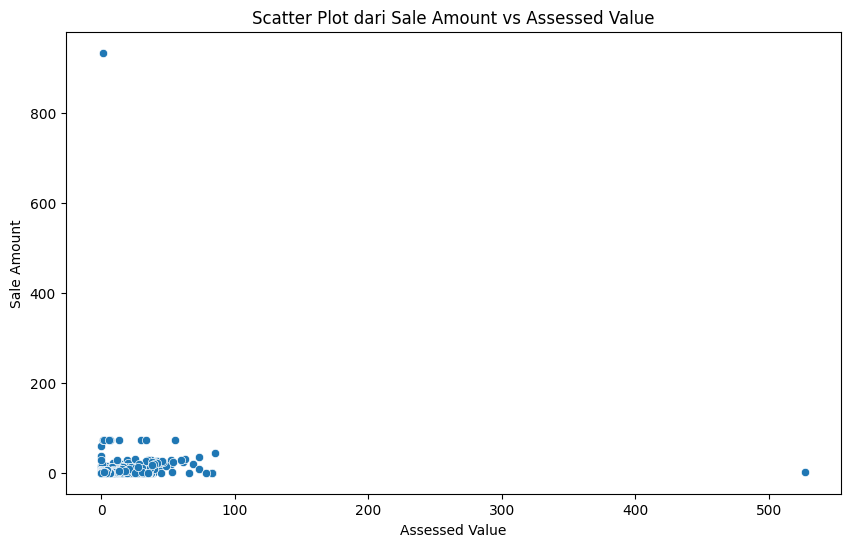

In [ ]:

# Scatter plot dari Sale Amount vs Assessed Value
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Assessed Value', y='Sale Amount', data=df)
plt.title('Scatter Plot dari Sale Amount vs Assessed Value')
plt.xlabel('Assessed Value')
plt.ylabel('Sale Amount')
plt.show()



# Train-Test Split

In [ ]:
# Menentukan kolom fitur dan kolom target
X = df[['Assessed Value', 'Sale Amount', 'Sales Ratio', 'Years until sold']]
y = df['Property Type']

# Memisahkan kumpulan data menjadi kumpulan training dan testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan bentuk set training dan testing
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((797770, 4), (199443, 4), (797770,), (199443,))

# Classification Model Training
Saya Menggunakan Logistic Regression

In [7]:
# Inisialisasi modelnya
logistic_regression = LogisticRegression(random_state=42)

# Melatih model Logistic Regression
logistic_regression.fit(X_train, y_train)

# Memprediksi test set menggunakan Logistic Regression
y_pred_logistic = logistic_regression.predict(X_test)

# Evaluasi model Logistic Regression
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logistic))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

/home/codespace/.local/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Classification Report:


/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

    Apartments       0.00      0.00      0.00       107
    Commercial       0.00      0.00      0.00       402
         Condo       0.00      0.00      0.00     20978
   Four Family       0.00      0.00      0.00       442
    Industrial       0.00      0.00      0.00        50
           Nan       0.67      0.01      0.02     76798
Public Utility       0.00      0.00      0.00         2
   Residential       0.00      0.00      0.00     12094
 Single Family       0.40      1.00      0.57     80199
  Three Family       0.00      0.00      0.00      2517
    Two Family       0.00      0.00      0.00      5228
   Vacant Land       0.00      0.00      0.00       626

      accuracy                           0.41    199443
     macro avg       0.09      0.08      0.05    199443
  weighted avg       0.42      0.41      0.24    199443

Confusion Matrix:
[[    0     0     0     0     0     7     0     0   100     0     0     0]
 [    0 

# Model Evaluation
Evaluasi kinerja model menggunakan  set testing menggunakan metrics contohnya seperti accuracy, precision, recall, dan F1-score.

In [8]:
# Model Evaluation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluasi hasil model Logistic Regression 
print("Logistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_logistic):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logistic, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_logistic, average='weighted'):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_logistic, average='weighted'):.4f}")

Logistic Regression Evaluation:
Accuracy: 0.4051


/home/codespace/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Precision: 0.4186
Recall: 0.4051
F1 Score: 0.2397


24/12/11 01:09:57 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
24/12/11 01:09:57 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
24/12/11 01:10:06 ERROR StrongWolfeLineSearch: Encountered bad values in function evaluation. Decreasing step size to 0.5
24/12/11 01:10:06 ERROR StrongWolfeLineSearch: Encountered bad values in function evaluation. Decreasing step size to 0.5
24/12/11 01:10:06 ERROR StrongWolfeLineSearch: Encountered bad values in function evaluation. Decreasing step size to 0.5
24/12/11 01:10:07 ERROR StrongWolfeLineSearch: Encountered bad values in function evaluation. Decreasing step size to 0.25
24/12/11 01:10:07 ERROR StrongWolfeLineSearch: Encountered bad values in function evaluation. Decreasing step size to 0.125
24/12/11 01:10:07 ERROR StrongWolfeLineSearch: Encountered bad values in function evaluation. Decreasing step size to 0.0625
24/12/11 01:10:08 ERROR StrongWolfeLineSearch

Accuracy: 0.4058


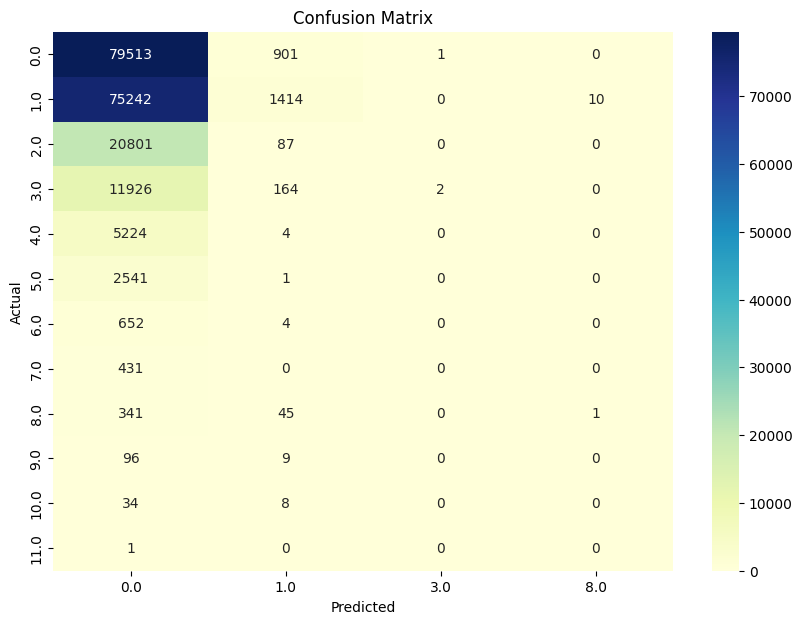

In [3]:
# Import Libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Initialize Spark Session
spark = SparkSession.builder.appName("BigDataAnalysis").getOrCreate()

# Load Dataset
data = spark.read.csv("../Datasets/Real Estate.csv", header=True, inferSchema=True)

# Data Cleaning
# Drop rows with missing values
data = data.dropna()

# Convert categorical columns to numerical
indexers = [StringIndexer(inputCol=column, outputCol=column+"_index").fit(data) for column in ["Property Type", "Residential Type"]]
pipeline = Pipeline(stages=indexers)
data = pipeline.fit(data).transform(data)

# Data Normalization
# Assemble features into a single vector
assembler = VectorAssembler(inputCols=["Assessed Value", "Sale Amount", "Sales Ratio", "Years until sold"], outputCol="features")
data = assembler.transform(data)

# Standardize the features
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
scaler_model = scaler.fit(data)
data = scaler_model.transform(data)

# Train-Test Split
train_data, test_data = data.randomSplit([0.8, 0.2], seed=42)

# Classification Model Training
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="Property Type_index")
model = lr.fit(train_data)

# Model Evaluation
predictions = model.transform(test_data)
evaluator = MulticlassClassificationEvaluator(labelCol="Property Type_index", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)
print(f"Accuracy: {accuracy:.4f}")

# Data Visualization
# Convert Spark DataFrame to Pandas DataFrame for visualization
pandas_df = predictions.select("Property Type_index", "prediction").toPandas()

# Plot confusion matrix
confusion_matrix = pd.crosstab(pandas_df["Property Type_index"], pandas_df["prediction"], rownames=["Actual"], colnames=["Predicted"])
plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix")
plt.show()